# 1BM110 - Assignment 1 - Group 7

**Students & IDs** \
Kazimir Breuer - 1574639 \
Daphne Gomes de Mesquita - 1678507 \
Isabelle Weenink - 1722239  \
Renske Quekel - ??

**Date** \
10th of March 2026

## Import Libraries


In [325]:
# Import libraries
import pandas as pd
import numpy as np  
import plotly.express as px
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

---

# 1. Load the Dataset (3 pts)

In this step both datasets are loaded. For all columns of each set it is checked whether the correct datatype is applied. 

Columns where all values are missing or equal to zero are removed. 

Lastly, a basic statistic description of the numerical variables is provided. 





## Load Data

In [326]:
# Load datasets
df   = pd.read_csv('energy_generation_train.csv')  # train set
test = pd.read_csv('energy_generation_test.csv')   # test set



In [327]:
print("Train set:")
display(df.head())

print("Test set:")
display(test.head())


Train set:


,DateTime,Biomass,Fossil Brown coal/Lignite,Fossil Coal-derived gas,Fossil Gas,Fossil Hard coal,Fossil Oil,Fossil Oil shale,Fossil Peat,Geothermal,...,Hydro Run-of-river and poundage,Hydro Water Reservoir,Marine,Nuclear,Other,Other renewable,Solar,Waste,Wind Offshore,Wind Onshore
0,2023-01-01 00:00:00,0.0,NaN,NaN,919.0,1225.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,485.0,161.0,NaN,1.0,69.0,1893.0,807.0
1,2023-01-01 00:15:00,0.0,NaN,NaN,921.0,1235.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,485.0,139.0,NaN,1.0,70.0,1367.0,741.0
2,2023-01-01 00:30:00,0.0,NaN,NaN,922.0,1249.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,485.0,139.0,NaN,1.0,69.0,1052.0,686.0
3,2023-01-01 00:45:00,0.0,NaN,NaN,966.0,1254.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,485.0,140.0,NaN,1.0,68.0,1090.0,682.0
4,2023-01-01 01:00:00,0.0,NaN,NaN,999.0,1258.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,485.0,137.0,NaN,1.0,68.0,1082.0,760.0


Test set:


,DateTime,Biomass,Fossil Brown coal/Lignite,Fossil Coal-derived gas,Fossil Gas,Fossil Hard coal,Fossil Oil,Fossil Oil shale,Fossil Peat,Geothermal,...,Hydro Run-of-river and poundage,Hydro Water Reservoir,Marine,Nuclear,Other,Other renewable,Solar,Waste,Wind Offshore,Wind Onshore
0,2024-02-01 00:00:00,0.0,NaN,NaN,1795.0,950.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,486.0,185.0,NaN,0.0,69.0,3260.0,1207.0
1,2024-02-01 00:15:00,0.0,NaN,NaN,1586.0,958.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,486.0,206.0,NaN,0.0,70.0,3269.0,1199.0
2,2024-02-01 00:30:00,0.0,NaN,NaN,1349.0,1055.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,486.0,208.0,NaN,0.0,69.0,3272.0,1180.0
3,2024-02-01 00:45:00,0.0,NaN,NaN,1264.0,997.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,486.0,184.0,NaN,0.0,64.0,3275.0,1180.0
4,2024-02-01 01:00:00,0.0,NaN,NaN,1278.0,982.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,486.0,184.0,NaN,0.0,61.0,3277.0,1183.0


## Ensure Correct Data Types
First the data types for each columns are checked. Then the incorrect types are converted. Lastly the it is checked whether the conversion is applied correctly. 


Convert columns to appropriate data types:
- **float/int** for numeric quantities
- **object** for categorical variables
- **datetime** for dates

In [328]:
# Show datatypes for both sets
print("Train set:")
display(pd.DataFrame({'Data Type': df.dtypes}))

print("Test set:")
display(pd.DataFrame({'Data Type': test.dtypes}))


Train set:


,Data Type
DateTime,str
Biomass,float64
Fossil Brown coal/Lignite,float64
Fossil Coal-derived gas,float64
Fossil Gas,float64
Fossil Hard coal,float64
Fossil Oil,float64
Fossil Oil shale,float64
Fossil Peat,float64
Geothermal,float64


Test set:


,Data Type
DateTime,str
Biomass,float64
Fossil Brown coal/Lignite,float64
Fossil Coal-derived gas,float64
Fossil Gas,float64
Fossil Hard coal,float64
Fossil Oil,float64
Fossil Oil shale,float64
Fossil Peat,float64
Geothermal,float64


In [329]:
# Ensure all columns have the correct data type for both sets
for dataset in [df, test]:
    dataset['DateTime'] = pd.to_datetime(dataset['DateTime'])
    numeric_cols = dataset.columns.drop('DateTime')
    dataset[numeric_cols] = dataset[numeric_cols].apply(pd.to_numeric, errors='coerce')


In [330]:
# Verify data types are correct now
print("Train set:")
display(pd.DataFrame({'Data Type': df.dtypes}))

print("Test set:")
display(pd.DataFrame({'Data Type': test.dtypes}))


Train set:


,Data Type
DateTime,datetime64[us]
Biomass,float64
Fossil Brown coal/Lignite,float64
Fossil Coal-derived gas,float64
Fossil Gas,float64
Fossil Hard coal,float64
Fossil Oil,float64
Fossil Oil shale,float64
Fossil Peat,float64
Geothermal,float64


Test set:


,Data Type
DateTime,datetime64[us]
Biomass,float64
Fossil Brown coal/Lignite,float64
Fossil Coal-derived gas,float64
Fossil Gas,float64
Fossil Hard coal,float64
Fossil Oil,float64
Fossil Oil shale,float64
Fossil Peat,float64
Geothermal,float64


## Data Inspection

Display the first few rows and basic information about the dataset.

In [331]:
# Display basic statistics

print("\nRemaining columns:", df.columns.tolist())
df.head()



Remaining columns: ['DateTime', 'Biomass', 'Fossil Brown coal/Lignite', 'Fossil Coal-derived gas', 'Fossil Gas', 'Fossil Hard coal', 'Fossil Oil', 'Fossil Oil shale', 'Fossil Peat', 'Geothermal', 'Hydro Pumped Storage', 'Hydro Pumped Storage.1', 'Hydro Run-of-river and poundage', 'Hydro Water Reservoir', 'Marine', 'Nuclear', 'Other', 'Other renewable', 'Solar', 'Waste', 'Wind Offshore', 'Wind Onshore']


,DateTime,Biomass,Fossil Brown coal/Lignite,Fossil Coal-derived gas,Fossil Gas,Fossil Hard coal,Fossil Oil,Fossil Oil shale,Fossil Peat,Geothermal,...,Hydro Run-of-river and poundage,Hydro Water Reservoir,Marine,Nuclear,Other,Other renewable,Solar,Waste,Wind Offshore,Wind Onshore
0,2023-01-01 00:00:00,0.0,NaN,NaN,919.0,1225.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,485.0,161.0,NaN,1.0,69.0,1893.0,807.0
1,2023-01-01 00:15:00,0.0,NaN,NaN,921.0,1235.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,485.0,139.0,NaN,1.0,70.0,1367.0,741.0
2,2023-01-01 00:30:00,0.0,NaN,NaN,922.0,1249.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,485.0,139.0,NaN,1.0,69.0,1052.0,686.0
3,2023-01-01 00:45:00,0.0,NaN,NaN,966.0,1254.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,485.0,140.0,NaN,1.0,68.0,1090.0,682.0
4,2023-01-01 01:00:00,0.0,NaN,NaN,999.0,1258.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,485.0,137.0,NaN,1.0,68.0,1082.0,760.0


## Check Columns with All Missing or Zero Values and remove them

Identify and remove columns where:
- All values are missing (NaN)
- All values equal zero

### Check columns 


In [332]:
# Count missing (NaN), zero, and available values per column for both sets
for label, dataset in [("Train", df), ("Test", test)]:
    cols      = dataset.select_dtypes(include="number").columns
    missing   = dataset[cols].isnull().sum()
    zeros     = (dataset[cols] == 0).sum()
    available = dataset[cols].notna().sum() - zeros
    summary   = pd.DataFrame({
        "Missing (NaN)": missing,
        "Zero values"  : zeros,
        "Available"    : available
    })
    print(f"=== {label} set ===")
    display(summary)
    print()


=== Train set ===


,Missing (NaN),Zero values,Available
Biomass,26,36166,0
Fossil Brown coal/Lignite,36192,0,0
Fossil Coal-derived gas,36192,0,0
Fossil Gas,27,3,36162
Fossil Hard coal,27,4007,32158
Fossil Oil,36192,0,0
Fossil Oil shale,36192,0,0
Fossil Peat,36192,0,0
Geothermal,36192,0,0
Hydro Pumped Storage,36192,0,0



=== Test set ===


,Missing (NaN),Zero values,Available
Biomass,46,33270,0
Fossil Brown coal/Lignite,33316,0,0
Fossil Coal-derived gas,33316,0,0
Fossil Gas,43,99,33174
Fossil Hard coal,45,6477,26794
Fossil Oil,33316,0,0
Fossil Oil shale,33316,0,0
Fossil Peat,33316,0,0
Geothermal,33316,0,0
Hydro Pumped Storage,33316,0,0


### Remove columns

In [333]:
# Drop columns where all values are either NaN or zero, keep only shared columns

for label, dataset in [("Train", df), ("Test", test)]:
    drop_cols = [c for c in dataset.select_dtypes(include="number").columns
                 if dataset[c].dropna().eq(0).all()]
    dataset.drop(columns=drop_cols, inplace=True)
    print(f"{label}: dropped {drop_cols}")

# Keep only columns present in both sets
shared_cols = ["DateTime"] + sorted(set(df.columns) & set(test.columns) - {"DateTime"})
df   = df[shared_cols]
test = test[shared_cols]

print(f"\nShared columns: {shared_cols}")



Train: dropped ['Biomass', 'Fossil Brown coal/Lignite', 'Fossil Coal-derived gas', 'Fossil Oil', 'Fossil Oil shale', 'Fossil Peat', 'Geothermal', 'Hydro Pumped Storage', 'Hydro Pumped Storage.1', 'Hydro Run-of-river and poundage', 'Hydro Water Reservoir', 'Marine', 'Other renewable']
Test: dropped ['Biomass', 'Fossil Brown coal/Lignite', 'Fossil Coal-derived gas', 'Fossil Oil', 'Fossil Oil shale', 'Fossil Peat', 'Geothermal', 'Hydro Pumped Storage', 'Hydro Pumped Storage.1', 'Hydro Run-of-river and poundage', 'Hydro Water Reservoir', 'Marine', 'Other renewable']

Shared columns: ['DateTime', 'Fossil Gas', 'Fossil Hard coal', 'Nuclear', 'Other', 'Solar', 'Waste', 'Wind Offshore', 'Wind Onshore']


## Basic Statistics of Numerical Variables

Display descriptive statistics including:
- Mean
- Minimum
- Maximum
- Standard deviation
- Quartiles

In [334]:
# Descriptive statistics for both sets
print("Train set:")
display(df.describe())

print("Test set:")
display(test.describe())


Train set:


,DateTime,Fossil Gas,Fossil Hard coal,Nuclear,Other,Solar,Waste,Wind Offshore,Wind Onshore
count,36192,36165.000000,36165.000000,36166.000000,36166.000000,36166.000000,36165.000000,36166.000000,36166.000000
mean,2023-07-17 16:57:18.859416,3512.526780,1362.925702,433.143837,351.869076,33.591412,62.448140,1296.396643,431.281867
min,2023-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2023-04-11 05:56:15,1525.000000,545.000000,470.000000,60.000000,0.000000,66.000000,415.000000,123.000000
50%,2023-07-16 11:52:30,2874.000000,1204.000000,475.000000,258.000000,1.000000,70.000000,1120.000000,337.000000
75%,2023-10-20 17:48:45,5263.000000,2147.000000,484.000000,562.000000,43.000000,71.000000,2111.000000,720.000000
max,2024-01-31 23:45:00,9666.000000,3912.000000,490.000000,11638.000000,252.000000,89.000000,3339.000000,1226.000000
std,NaN,2256.922636,999.446391,135.731203,292.844467,56.984666,17.870353,966.509495,347.334153


Test set:


,DateTime,Fossil Gas,Fossil Hard coal,Nuclear,Other,Solar,Waste,Wind Offshore,Wind Onshore
count,33316,33273.000000,33271.000000,33273.000000,33273.000000,33272.000000,33273.000000,33273.000000,33273.000000
mean,2024-08-03 13:54:11.464761,3523.873561,1239.446575,380.551198,173.465002,32.775667,64.897635,1693.640459,376.371262
min,2024-02-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2024-05-07 18:11:15,1509.000000,280.000000,466.000000,45.000000,0.000000,57.000000,492.000000,88.000000
50%,2024-08-02 12:22:30,2706.000000,880.000000,475.000000,60.000000,1.000000,70.000000,1404.000000,275.000000
75%,2024-11-01 05:33:45,5148.000000,2041.000000,485.000000,214.000000,43.000000,72.000000,2925.000000,616.000000
max,2025-01-31 23:45:00,11004.000000,3926.000000,491.000000,2011.000000,251.000000,106.000000,4384.000000,1232.000000
std,NaN,2435.205330,1167.231757,192.315344,209.187260,54.603070,10.888196,1306.264129,334.794380


---

# 2. Data Pre-processing (7 pts)



## 2.1 Data Integration

### Add in Total Energy column (non-renewable sources)

In [335]:
# Make total energy column by summing the three non-renewable energy sources
df['Total_Energy'] = df['Fossil Gas'] + df['Fossil Hard coal'] + df['Nuclear']
test['Total_Energy'] = test['Fossil Gas'] + test['Fossil Hard coal'] + test['Nuclear']


### Sort data chronologically 

**Why:** This step is necessary as a machine learning model expects the training and test set to have the same structure. Therefore, it is important that both sets have the same columns. Furthermore, converting datetime columns into a standardized format ensures correct temporal ordering and prevents errors in time-based aggregation or modeling. Integration reduces the risk of inconsistencies between the sets. 

**Result:** After performing data integration, it is expected that the train and test set have the same structure and that the columns are aligned and ordered the same way. Next to that, the DateTime column should be in the same format and both datasets should be sorted in the same way.



In [336]:
# Convert DateTime column to proper datetime type
df["DateTime"] = pd.to_datetime(df["DateTime"])
test["DateTime"] = pd.to_datetime(test["DateTime"])

# Sort both datasets chronologically
df = df.sort_values("DateTime").reset_index(drop=True)
test = test.sort_values("DateTime").reset_index(drop=True)

# Show shape and first rows for train set
print("Train set:")
print("Shape:", df.shape)
display(df.head())

# Show shape and first rows for test set
print("Test set:")
print("Shape:", test.shape)
display(test.head())


Train set:
Shape: (36192, 10)


,DateTime,Fossil Gas,Fossil Hard coal,Nuclear,Other,Solar,Waste,Wind Offshore,Wind Onshore,Total_Energy
0,2023-01-01 00:00:00,919.0,1225.0,485.0,161.0,1.0,69.0,1893.0,807.0,2629.0
1,2023-01-01 00:15:00,921.0,1235.0,485.0,139.0,1.0,70.0,1367.0,741.0,2641.0
2,2023-01-01 00:30:00,922.0,1249.0,485.0,139.0,1.0,69.0,1052.0,686.0,2656.0
3,2023-01-01 00:45:00,966.0,1254.0,485.0,140.0,1.0,68.0,1090.0,682.0,2705.0
4,2023-01-01 01:00:00,999.0,1258.0,485.0,137.0,1.0,68.0,1082.0,760.0,2742.0


Test set:
Shape: (33316, 10)


,DateTime,Fossil Gas,Fossil Hard coal,Nuclear,Other,Solar,Waste,Wind Offshore,Wind Onshore,Total_Energy
0,2024-02-01 00:00:00,1795.0,950.0,486.0,185.0,0.0,69.0,3260.0,1207.0,3231.0
1,2024-02-01 00:15:00,1586.0,958.0,486.0,206.0,0.0,70.0,3269.0,1199.0,3030.0
2,2024-02-01 00:30:00,1349.0,1055.0,486.0,208.0,0.0,69.0,3272.0,1180.0,2890.0
3,2024-02-01 00:45:00,1264.0,997.0,486.0,184.0,0.0,64.0,3275.0,1180.0,2747.0
4,2024-02-01 01:00:00,1278.0,982.0,486.0,184.0,0.0,61.0,3277.0,1183.0,2746.0


## 2.2 Data Cleaning

## Fill and remove timestamps

We want each dat to have 96 datapoints. Because 24 hours with 15 min intervals gives us 96 timestamps. 

### Remove Duplicate Timestamps

In [337]:
def remove_duplicate_timestamps(dataset, label):
    # Sort so that for each DateTime, rows with higher Total_Energy come first
    # This ensures we keep the non-zero row when one exists
    dataset_sorted = dataset.sort_values(["DateTime", "Total_Energy"], ascending=[True, False])
    cleaned = dataset_sorted.drop_duplicates(subset="DateTime", keep="first") \
                            .sort_values("DateTime").reset_index(drop=True)

    n_removed = len(dataset) - len(cleaned)
    print(f"=== {label} set ===")
    print(f"  Rows before: {len(dataset)}, rows after: {len(cleaned)}, duplicates removed: {n_removed}")
    return cleaned

df   = remove_duplicate_timestamps(df,   "Train")
test = remove_duplicate_timestamps(test, "Test")



=== Train set ===
  Rows before: 36192, rows after: 36192, duplicates removed: 0
=== Test set ===
  Rows before: 33316, rows after: 33312, duplicates removed: 4


### Add in missing timestamps

Add in missing timestamps and use linear interpolatation to fill the gaps. 

In [338]:
def add_missing_timestamps(dataset, label):
    full_range = pd.date_range(
        start=dataset["DateTime"].min(),
        end=dataset["DateTime"].max(),
        freq="15min"
    )

    missing_times = full_range.difference(dataset["DateTime"])

    print(f"=== {label} set ===")
    print(f"  Expected  : {len(full_range)} timestamps")
    print(f"  Present   : {len(dataset)} timestamps")
    print(f"  Added     : {len(missing_times)} missing timestamps (interpolated)")

    if len(missing_times) > 0:
        empty_rows = pd.DataFrame({"DateTime": missing_times})
        dataset = pd.concat([dataset, empty_rows], ignore_index=True)
        dataset = dataset.sort_values("DateTime").reset_index(drop=True)

        # Interpolate NaN values using time-based linear interpolation
        dataset = dataset.set_index("DateTime")
        dataset = dataset.interpolate(method="time")
        dataset = dataset.ffill().bfill()  # handle edges if NaN at start/end
        dataset = dataset.reset_index()

    return dataset

df   = add_missing_timestamps(df,   "Train")
test = add_missing_timestamps(test, "Test")

df.head()


=== Train set ===
  Expected  : 38016 timestamps
  Present   : 36192 timestamps
  Added     : 1824 missing timestamps (interpolated)
=== Test set ===
  Expected  : 35136 timestamps
  Present   : 33312 timestamps
  Added     : 1824 missing timestamps (interpolated)


,DateTime,Fossil Gas,Fossil Hard coal,Nuclear,Other,Solar,Waste,Wind Offshore,Wind Onshore,Total_Energy
0,2023-01-01 00:00:00,919.0,1225.0,485.0,161.0,1.0,69.0,1893.0,807.0,2629.0
1,2023-01-01 00:15:00,921.0,1235.0,485.0,139.0,1.0,70.0,1367.0,741.0,2641.0
2,2023-01-01 00:30:00,922.0,1249.0,485.0,139.0,1.0,69.0,1052.0,686.0,2656.0
3,2023-01-01 00:45:00,966.0,1254.0,485.0,140.0,1.0,68.0,1090.0,682.0,2705.0
4,2023-01-01 01:00:00,999.0,1258.0,485.0,137.0,1.0,68.0,1082.0,760.0,2742.0


## Handle Missing Values

**Why:** Handling missing values is important, because machine learning models cannot work with missing (NaN) values. If it is ignored, it may cause errors during training or lead to biased predictions. In time series data, gaps in the sequence can also disrupt the temporal structure that the model tries to learn.


**Result:** The expected result is a complete dataset without missing values, where the time series remains continuous and suitable for modeling.

### Fill missing values with 0

In [339]:
# Check missing values in both sets before handling them
print("Train set:")
print(df.isnull().sum())

print("\nTest set:")
print(test.isnull().sum())

# Temporarily fill missing values with 0 — to be replaced with proper imputation later
df.fillna(0, inplace=True)
test.fillna(0, inplace=True)

# Verify all missing values are now filled
print("Train set:")
display(df.describe())

print("Test set:")
display(test.describe())
 


Train set:
DateTime            0
Fossil Gas          0
Fossil Hard coal    0
Nuclear             0
Other               0
Solar               0
Waste               0
Wind Offshore       0
Wind Onshore        0
Total_Energy        0
dtype: int64

Test set:
DateTime            0
Fossil Gas          0
Fossil Hard coal    0
Nuclear             0
Other               0
Solar               0
Waste               0
Wind Offshore       0
Wind Onshore        0
Total_Energy        0
dtype: int64
Train set:


,DateTime,Fossil Gas,Fossil Hard coal,Nuclear,Other,Solar,Waste,Wind Offshore,Wind Onshore,Total_Energy
count,38016,38016.000000,38016.000000,38016.000000,38016.000000,38016.000000,38016.000000,38016.000000,38016.000000,38016.000000
mean,2023-07-17 23:52:30,3462.752683,1374.724156,434.086648,347.574824,32.024095,62.420441,1310.799400,434.851286,5271.562947
min,2023-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2023-04-09 23:56:15,1506.000000,552.000000,470.000000,58.000000,0.000000,66.000000,435.000000,129.000000,3046.451337
50%,2023-07-17 23:52:30,2764.000000,1229.000000,476.000000,254.000000,1.000000,70.000000,1146.000000,349.000000,4729.000000
75%,2023-10-24 23:48:45,5189.000000,2136.219072,484.000000,556.000000,39.000000,71.000000,2110.000000,724.000000,6985.000000
max,2024-01-31 23:45:00,9666.000000,3912.000000,490.000000,11638.000000,252.000000,89.000000,3339.000000,1226.000000,13228.000000
std,NaN,2243.002055,993.686018,134.656543,292.829163,56.074742,18.086052,963.359782,343.654651,2724.299518


Test set:


,DateTime,Fossil Gas,Fossil Hard coal,Nuclear,Other,Solar,Waste,Wind Offshore,Wind Onshore,Total_Energy
count,35136,35136.000000,35136.000000,35136.000000,35136.000000,35136.000000,35136.000000,35136.000000,35136.000000,35136.000000
mean,2024-08-01 23:52:30,3529.395976,1268.004041,383.220543,175.133182,31.071977,65.265013,1695.427468,375.235485,5180.624246
min,2024-02-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2024-05-02 11:56:15,1541.000000,281.000000,466.000000,46.000000,0.000000,57.000000,501.000000,88.000000,2469.000000
50%,2024-08-01 23:52:30,2746.000000,945.000000,477.000000,61.635650,1.000000,71.000000,1407.000000,275.000000,4324.000000
75%,2024-11-01 11:48:45,5099.000000,2108.000000,485.000000,215.000000,38.000000,72.000000,2911.000000,619.025087,7118.000000
max,2025-01-31 23:45:00,11004.000000,3926.000000,491.000000,2011.000000,251.000000,106.000000,4384.000000,1232.000000,15346.000000
std,NaN,2405.462579,1171.670590,190.514142,208.641729,53.630340,10.759624,1299.302556,332.568264,3314.392958


In [340]:
for label, dataset in [("Train", df), ("Test", test)]:
    cols    = dataset.select_dtypes(include="number").columns
    missing = dataset[cols].isnull().sum()
    zeros   = (dataset[cols] == 0).sum()
    summary = pd.DataFrame({"Missing (NaN)": missing, "Zero values": zeros})
    print(f"=== {label} set ===")
    display(summary)
    print()



=== Train set ===


,Missing (NaN),Zero values
Fossil Gas,0,3
Fossil Hard coal,0,4007
Nuclear,0,3216
Other,0,3
Solar,0,11239
Waste,0,1507
Wind Offshore,0,6
Wind Onshore,0,7
Total_Energy,0,3



=== Test set ===


,Missing (NaN),Zero values
Fossil Gas,0,99
Fossil Hard coal,0,6766
Nuclear,0,6907
Other,0,99
Solar,0,10861
Waste,0,100
Wind Offshore,0,99
Wind Onshore,0,319
Total_Energy,0,99


### Linear interpolation for zero values

# Linear interpolation for timestamps where all energy values are zero
def interpolate_zero_blocks(dataset, label):
    dataset = dataset.copy().sort_values("DateTime").reset_index(drop=True)
    energy_cols = [c for c in dataset.select_dtypes(include="number").columns
                   if c != "Total_Energy"]

    # A row is a zero-block if all energy columns equal zero
    zero_mask = (dataset[energy_cols] == 0).all(axis=1)

    # Find consecutive zero blocks
    blocks = []
    in_block = False
    for i, is_zero in enumerate(zero_mask):
        if is_zero and not in_block:
            in_block = True
            start_idx = i
        elif not is_zero and in_block:
            in_block = False
            blocks.append((start_idx, i - 1))
    if in_block:
        blocks.append((start_idx, len(dataset) - 1))

    print(f"=== {label} set: {len(blocks)} zero block(s) found ===")

    for start, end in blocks:
        before_idx = start - 1
        after_idx  = end + 1

        if before_idx < 0 or after_idx >= len(dataset):
            print(f"  Skipping {dataset.loc[start, 'DateTime']} → {dataset.loc[end, 'DateTime']} (no boundary values)")
            continue

        n = end - start + 1
        print(f"  Interpolating {dataset.loc[start, 'DateTime']} → {dataset.loc[end, 'DateTime']} ({n} timestamp(s))")

        for col in energy_cols:
            before_val = dataset.loc[before_idx, col]
            after_val  = dataset.loc[after_idx,  col]
            for step, idx in enumerate(range(start, end + 1), start=1):
                dataset.loc[idx, col] = before_val + (step / (n + 1)) * (after_val - before_val)

        # Recalculate Total_Energy
        dataset.loc[start:end, "Total_Energy"] = dataset.loc[start:end, energy_cols].sum(axis=1)

    return dataset

df   = interpolate_zero_blocks(df,   "Train")
test = interpolate_zero_blocks(test, "Test")


### Step: Handle Outliers

**Why:** Outliers are values that differ strongly from the rest of the data and may distort the  training process. If they are not treated, the model might focus too much on  abnormal observations instead of general patterns. This can reduce prediction accuracy and lead to unstable forecasts. Therefore, outliers are dealth with.

**Result:** The expected result is a dataset where extreme values are corrected, allowing the model to learn representative trends.

In [341]:
# Detect outliers using the IQR method for both train and test sets
def find_outliers_IQR(dataset):
    q1  = dataset.quantile(0.25)
    q3  = dataset.quantile(0.75)
    IQR = q3 - q1
    outliers = dataset[((dataset < (q1 - 1.5 * IQR)) | (dataset > (q3 + 1.5 * IQR)))]
    return outliers

for label, dataset in [("Train", df), ("Test", test)]:
    numeric_data = dataset.select_dtypes(include=[np.number])
    outliers     = find_outliers_IQR(numeric_data)

    summary = pd.DataFrame({
        "Outlier count": outliers.count(),
        "Max outlier":   outliers.max(),
        "Min outlier":   outliers.min(),
    })

    print(f"=== {label} set ===")
    display(summary)
    print()


=== Train set ===


,Outlier count,Max outlier,Min outlier
Fossil Gas,0,NaN,NaN
Fossil Hard coal,0,NaN,NaN
Nuclear,4101,448.0,0.0
Other,5,11638.0,1309.0
Solar,4931,252.0,98.0
Waste,7673,89.0,0.0
Wind Offshore,0,NaN,NaN
Wind Onshore,0,NaN,NaN
Total_Energy,30,13228.0,12896.0



=== Test set ===


,Outlier count,Max outlier,Min outlier
Fossil Gas,265,11004.0,10437.000000
Fossil Hard coal,0,NaN,NaN
Nuclear,7071,437.0,0.000000
Other,3422,2011.0,468.550173
Solar,4610,251.0,96.000000
Waste,602,106.0,0.000000
Wind Offshore,0,NaN,NaN
Wind Onshore,0,NaN,NaN
Total_Energy,554,15346.0,14092.000000


In [342]:
# Handle outliers
#willen we ze droppen of cappen? want alleen bij other is heel hoog maar dat isl ogisch. 

## 2.3 Data Reduction

### Step: Feature Selection

**Why:** Feature selection is choosing only the most relevant variables from the dataset and removing the ones that are not useful for the research. This is important, because not every variable contributes to the goal of the research, and some features may even add noise. If we keep too many irrelevant features, the model becomes more complex and harder to train, which can reduce performance.

**Result:** The expected result is a smaller dataset which consist of meaningful variables only

In [343]:
# Feature selection analysis




In [344]:
# Select features


### Step: Dimensionality Reduction (if applicable)

**Why:** [Explain why dimensionality reduction is necessary]

Idk of dit nodig is? ik denk het persoonlijk van niet. 

**Result:** [Describe the result]

In [345]:
# Dimensionality reduction



## 2.4 Data Transformation

### Step: Normalization/Standardization

**Why:** 
Our energy sources have very different scales (e.g., Fossil Gas reaches 10,000+ MW while Solar might only reach 200 MW). Without scaling, the model would mistakenly think Fossil Gas is "more important" just because the numbers are larger. By scaling everything between 0 and 1, we ensure that:

1. Every feature contributes equally to the model.
2. The neural network can identify patterns more easily using small, consistent numbers.

**Result:** We used the Min-Max Scaler to transform all numerical columns into a range of 0 to 1. The training data is now perfectly scaled, and the test data has been adjusted accordingly.

In [346]:
# Scale/normalize features

test = test.copy()

# 1. Initialize the scaler
scaler = MinMaxScaler(feature_range=(0, 1))

# 2. Select numeric columns (excluding DateTime)
numeric_cols = df.select_dtypes(include=['number']).columns

# 3. Fit on train, transform both
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
test[numeric_cols] = scaler.transform(test[numeric_cols])  # transform only, no re-fit

# 4. Verify scaling
print("Train set statistics:")
print(df[numeric_cols].describe().loc[['min', 'max']])

print("\nTest set statistics:")
print(test[numeric_cols].describe().loc[['min', 'max']])


Train set statistics:
     Fossil Gas  Fossil Hard coal  Nuclear  Other  Solar  Waste  \
min         0.0               0.0      0.0    0.0    0.0    0.0   
max         1.0               1.0      1.0    1.0    1.0    1.0   

     Wind Offshore  Wind Onshore  Total_Energy  
min            0.0           0.0           0.0  
max            1.0           1.0           1.0  

Test set statistics:
     Fossil Gas  Fossil Hard coal   Nuclear     Other     Solar     Waste  \
min    0.000000          0.000000  0.000000  0.000000  0.000000  0.000000   
max    1.138423          1.003579  1.002041  0.172796  0.996032  1.191011   

     Wind Offshore  Wind Onshore  Total_Energy  
min       0.000000      0.000000      0.000000  
max       1.312968      1.004894      1.160115  


## Feature Engineering

**Why:** [Explain why creating new features is beneficial]

**Result:** [Describe new features created]

### Engineer time-sensitive features

In [347]:
# Feature engineering: time-based features from DateTime
def engineer_time_features(dataset, label):
    dataset = dataset.copy()

    # Extract time-based features
    dataset["hour"]        = dataset["DateTime"].dt.hour
    dataset["minute"]      = dataset["DateTime"].dt.minute
    dataset["day_of_week"] = dataset["DateTime"].dt.dayofweek      # 0=Monday, 6=Sunday
    dataset["month"]       = dataset["DateTime"].dt.month
    dataset["quarter"]     = dataset["DateTime"].dt.quarter

    # Cyclical encoding for hour and month (avoids jump from 23→0 or Dec→Jan)
    dataset["hour_sin"]    = np.sin(2 * np.pi * dataset["hour"]  / 24)
    dataset["hour_cos"]    = np.cos(2 * np.pi * dataset["hour"]  / 24)
    dataset["month_sin"]   = np.sin(2 * np.pi * dataset["month"] / 12)
    dataset["month_cos"]   = np.cos(2 * np.pi * dataset["month"] / 12)

    print(f"=== {label} set ===")
    print(f"  Shape after feature engineering: {dataset.shape}")
    display(dataset[["DateTime", "hour", "minute", "day_of_week",
                      "month", "quarter",
                      "hour_sin", "hour_cos", "month_sin", "month_cos"]].head())
    return dataset

df   = engineer_time_features(df,   "Train")
test = engineer_time_features(test, "Test")



=== Train set ===
  Shape after feature engineering: (38016, 19)


,DateTime,hour,minute,day_of_week,month,quarter,hour_sin,hour_cos,month_sin,month_cos
0,2023-01-01 00:00:00,0,0,6,1,1,0.000000,1.000000,0.5,0.866025
1,2023-01-01 00:15:00,0,15,6,1,1,0.000000,1.000000,0.5,0.866025
2,2023-01-01 00:30:00,0,30,6,1,1,0.000000,1.000000,0.5,0.866025
3,2023-01-01 00:45:00,0,45,6,1,1,0.000000,1.000000,0.5,0.866025
4,2023-01-01 01:00:00,1,0,6,1,1,0.258819,0.965926,0.5,0.866025


=== Test set ===
  Shape after feature engineering: (35136, 19)


,DateTime,hour,minute,day_of_week,month,quarter,hour_sin,hour_cos,month_sin,month_cos
0,2024-02-01 00:00:00,0,0,3,2,1,0.000000,1.000000,0.866025,0.5
1,2024-02-01 00:15:00,0,15,3,2,1,0.000000,1.000000,0.866025,0.5
2,2024-02-01 00:30:00,0,30,3,2,1,0.000000,1.000000,0.866025,0.5
3,2024-02-01 00:45:00,0,45,3,2,1,0.000000,1.000000,0.866025,0.5
4,2024-02-01 01:00:00,1,0,3,2,1,0.258819,0.965926,0.866025,0.5


## Plots of energy generation over time

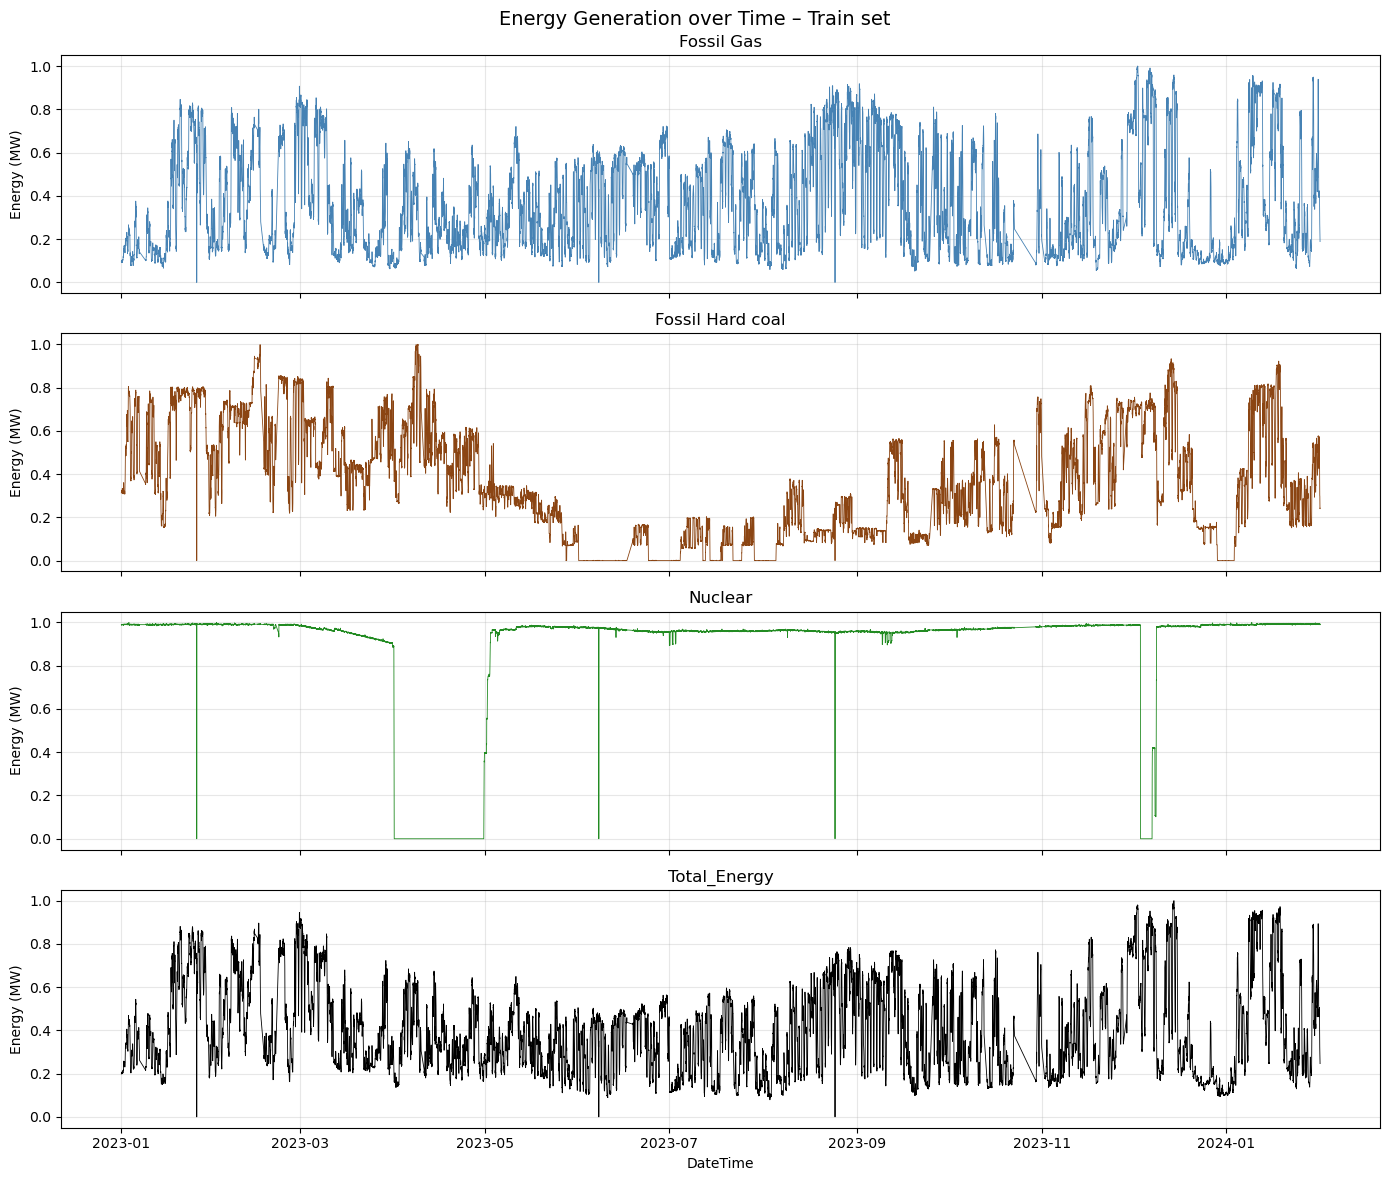

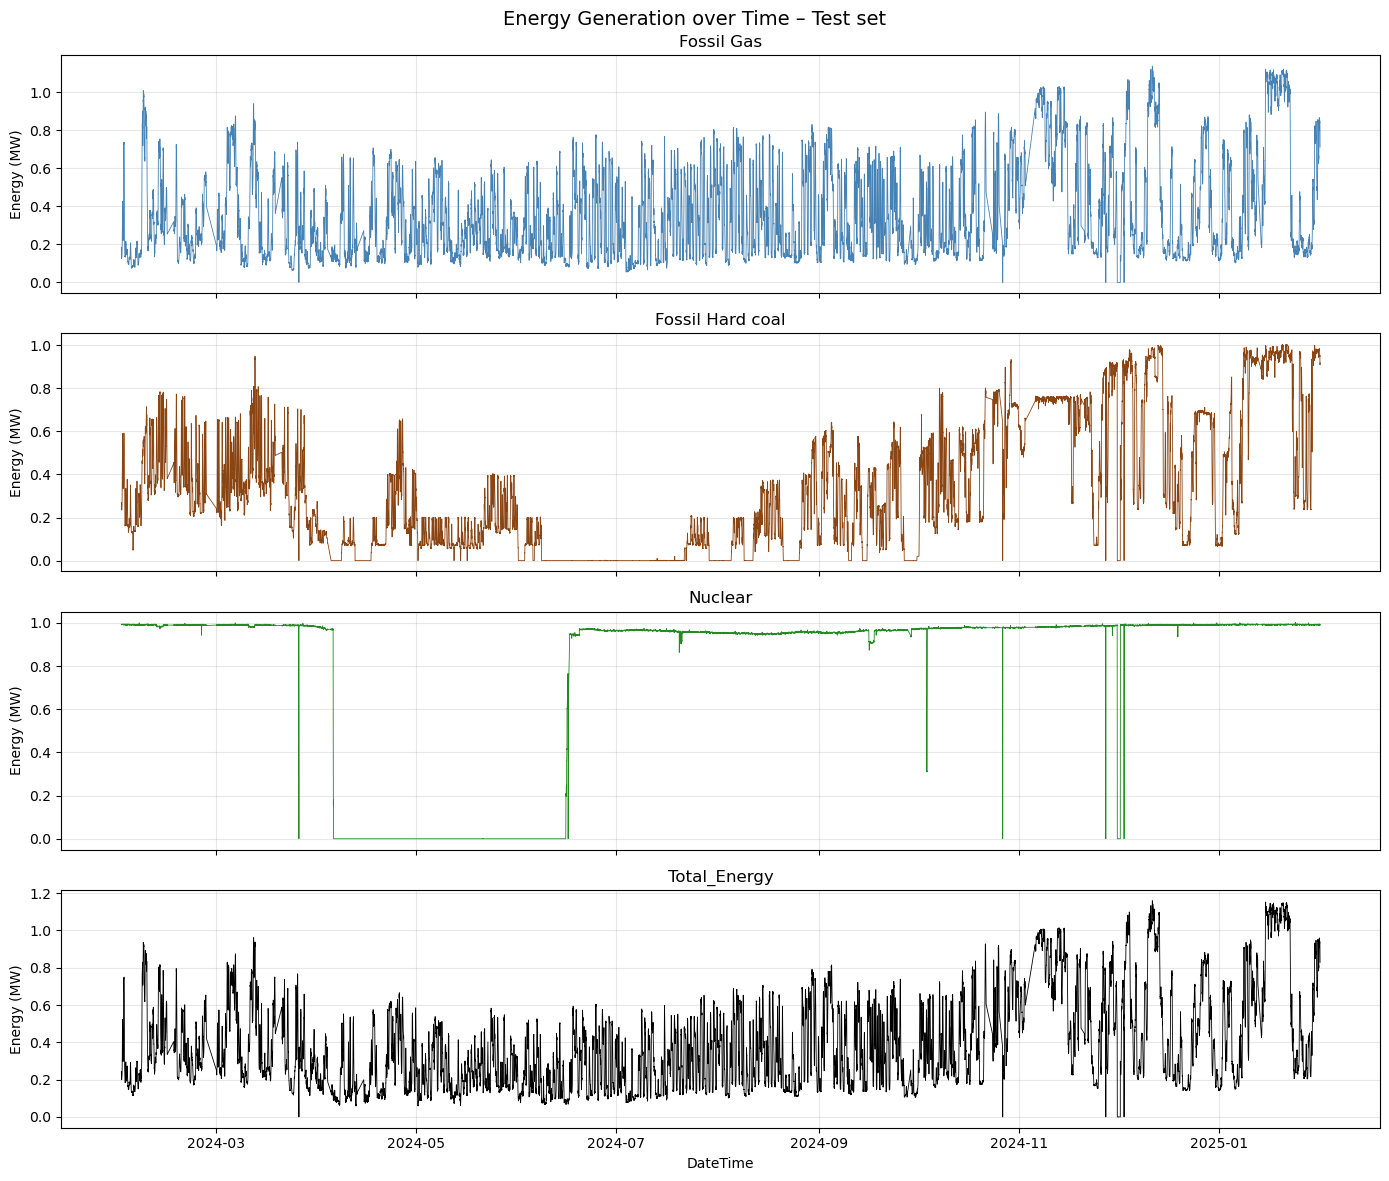

In [348]:
for label, dataset in [("Train", df), ("Test", test)]:
    fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

    cols   = ["Fossil Gas", "Fossil Hard coal", "Nuclear", "Total_Energy"]
    colors = ["steelblue", "saddlebrown", "forestgreen", "black"]

    for ax, col, color in zip(axes, cols, colors):
        ax.plot(dataset["DateTime"], dataset[col], color=color, linewidth=0.6)
        ax.set_title(col)
        ax.set_ylabel("Energy (MW)")
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("DateTime")
    fig.suptitle(f"Energy Generation over Time – {label} set", fontsize=14)
    plt.tight_layout()
    plt.show()

In [349]:
# Create new features


---

# 3. Organize Time-Dependent Data (4 pts)

## Time Series Organization Strategy

**Strategy Description:**

[Describe your strategy for organizing time-dependent data. Consider:
- How do you create sequences?
- What is your sequence length (window size)?
- Do you use overlapping windows?
- What is your prediction horizon?
- How do you handle the temporal ordering?]

**Motivation:**

[Explain why you chose this particular strategy]
36,000 observations over 13 months, the data has a 15-minute frequency

**Visual Representation:**

[Include a figure showing your windowing strategy]

<!-- Example: ![Windowing Strategy](images/windowing_strategy.png) -->

In [350]:
# Sort data by time
#already done in the beginning 
df = df.sort_values(by='DateTime').reset_index(drop=True)
print(df['DateTime'].head())

0   2023-01-01 00:00:00
1   2023-01-01 00:15:00
2   2023-01-01 00:30:00
3   2023-01-01 00:45:00
4   2023-01-01 01:00:00
Name: DateTime, dtype: datetime64[us]


In [351]:
# Create sequences/windows for time series
def create_sequences(df, sequence_length):
    """
    Converts a 2D dataframe into 3D arrays for RNN input.
    """
    # Extract only the numerical features (ignore DateTime for the math)
    data = df.select_dtypes(include=[np.number]).values
    
    X, y = [], []
    
    # Slide the window across the data
    for i in range(len(data) - sequence_length):
        # The past 'sequence_length' steps
        X.append(data[i : i + sequence_length])
        # The very next step after the window (predicting all features)
        y.append(data[i + sequence_length])
        
    return np.array(X), np.array(y)

# Set window size to 24 hours (96 steps of 15-minutes)
SEQ_LENGTH = 96

# Create sequences for the train set (df) and test set (test)
X_data, y_data = create_sequences(df, SEQ_LENGTH)
X_test, y_test = create_sequences(test, SEQ_LENGTH)

print(f"Original df shape: {df.shape}")
print(f"X_data (Features) shape: {X_data.shape} -> (Samples, Timesteps, Features)")
print(f"y_data (Targets) shape: {y_data.shape} -> (Samples, Features)")
print(f"Original test shape: {test.shape}")
print(f"X_test (Features) shape: {X_test.shape} -> (Samples, Timesteps, Features)")
print(f"y_test (Targets) shape: {y_test.shape} -> (Samples, Features)")

Original df shape: (38016, 19)
X_data (Features) shape: (37920, 96, 18) -> (Samples, Timesteps, Features)
y_data (Targets) shape: (37920, 18) -> (Samples, Features)
Original test shape: (35136, 19)
X_test (Features) shape: (35040, 96, 18) -> (Samples, Timesteps, Features)
y_test (Targets) shape: (35040, 18) -> (Samples, Features)


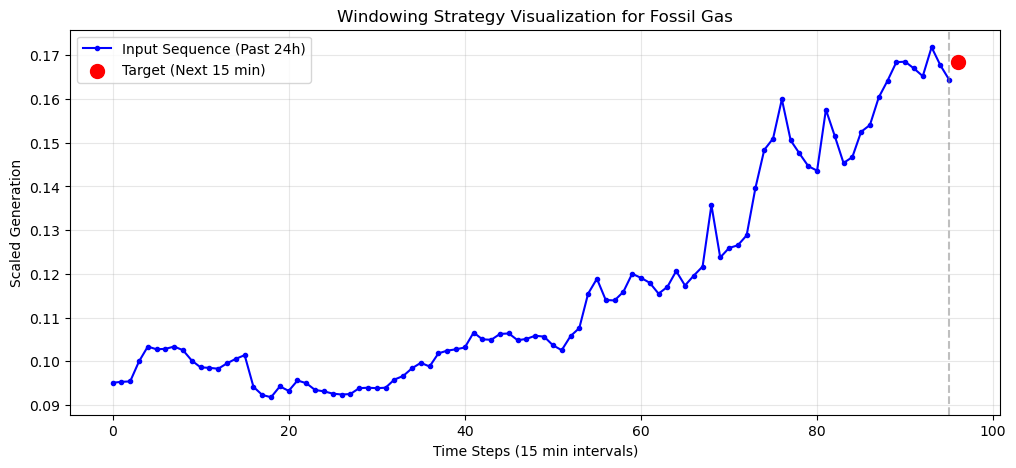

In [352]:
# Visualize the windowing strategy
# Let's visualize the very first sequence and its target for a specific feature
feature_idx = 0 # 'Fossil Gas' (assuming it's the first numerical column)
feature_name = df.select_dtypes(include=[np.number]).columns[feature_idx]

plt.figure(figsize=(12, 5))

# Plot the 96 steps of the input sequence (X)
plt.plot(range(SEQ_LENGTH), X_data[0, :, feature_idx], label='Input Sequence (Past 24h)', color='blue', marker='.')

# Plot the 1 step of the target (y)
plt.scatter(SEQ_LENGTH, y_data[0, feature_idx], color='red', s=100, label='Target (Next 15 min)', zorder=5)

plt.axvline(x=SEQ_LENGTH-1, color='gray', linestyle='--', alpha=0.5)
plt.title(f'Windowing Strategy Visualization for {feature_name}')
plt.xlabel('Time Steps (15 min intervals)')
plt.ylabel('Scaled Generation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---

# 4. Prepare Data for Model Selection and Evaluation (4 pts)

## Experimental Setup

**Data Splitting Strategy:**

[Describe how you split the data:
- Training set: X% (time period: ...)
- Validation set: Y% (time period: ...)
- Test set: Z% (time period: ...)]

**Validation Strategy:**

[Specify the validation approach:
- Hold-out validation
- Time series cross-validation
- Walk-forward validation
- Other]

**Rationale:**

[Explain why this setup is appropriate for time series data]

**Visual Summary:**

[Include a figure clearly showing the train/validation/test split]

<!-- Example: ![Experimental Setup](images/train_val_test_split.png) -->

# Split train set into train (80%) and validation (20%) (chronological split, no random shuffling)
split_date = "2023-12-01"

train = df[df["DateTime"] < split_date].reset_index(drop=True)
val   = df[df["DateTime"] >= split_date].reset_index(drop=True)

print(f"Train     : {train['DateTime'].min().date()} → {train['DateTime'].max().date()}  ({len(train)} rows)")
print(f"Validation: {val['DateTime'].min().date()}   → {val['DateTime'].max().date()}  ({len(val)} rows)")
print(f"Test      : {test['DateTime'].min().date()}  → {test['DateTime'].max().date()}  ({len(test)} rows)")


# Plot Total_Energy over time for train, validation, and test sets
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(train["DateTime"], train["Total_Energy"], label="Train",      color="steelblue",  linewidth=0.8)
ax.plot(val["DateTime"],   val["Total_Energy"],   label="Validation", color="orange",     linewidth=0.8)
ax.plot(test["DateTime"],  test["Total_Energy"],  label="Test",       color="green",      linewidth=0.8)

ax.set_title("Total Energy over Time — Train / Validation / Test")
ax.set_xlabel("DateTime")
ax.set_ylabel("Total Energy (MW)")
ax.legend()
plt.tight_layout()
plt.show()


In [353]:
# Display split information


---

# 5. Build RNN Prediction Model (5 pts)

## Model Architecture Selection

**Chosen Architecture:** [LSTM / GRU / Simple RNN / Bidirectional LSTM / etc.]

**Motivation:**

[Explain why you chose this particular RNN architecture for your problem]

## Hyperparameter Selection

**Selected/Optimized Hyperparameters:**

- Number of layers:
- Hidden units per layer:
- Dropout rate:
- Learning rate:
- Batch size:
- Number of epochs:
- Optimizer:
- Loss function:
- Other:

**Motivation:**

[Explain the reasoning behind your hyperparameter choices or the optimization strategy used]

In [354]:
# Define model architecture


In [355]:
# Display model summary


In [356]:
# Compile model


In [357]:
# Train model


---

# 6. Training and Validation Loss Analysis (2 pts)

## Loss Visualization

In [358]:
# Plot training and validation losses


## Loss Analysis

**Observed Trends:**

[Describe the trends you observe in the training and validation loss curves]

**Underfitting/Overfitting Assessment:**

[Analyze whether the model shows signs of:
- Underfitting (high training and validation loss)
- Overfitting (low training loss but high validation loss)
- Good fit (both losses decrease and converge)]

**Implications:**

[Discuss what these trends mean for model performance and potential improvements]

---

# 7. Model Evaluation (3 pts)

## Evaluation Metrics

**Selected Metrics:**

[List the metrics you will use, e.g.:
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)
- R² Score
- Others]

**Rationale:**

[Explain why these metrics are appropriate for your problem]

In [359]:
# Make predictions on test set


In [360]:
# Calculate evaluation metrics


In [361]:
# Display evaluation results


## Results Discussion

**Performance Summary:**

[Summarize the numerical results from your evaluation metrics]

**Interpretation:**

[Discuss what these results mean:
- How well does the model perform?
- Are the results acceptable for the problem domain?
- What are the strengths and weaknesses?
- How does it compare to baseline expectations?]

---

# 8. Predictions vs Ground Truth Visualization (2 pts)

In [362]:
# Create plot comparing predictions and ground truth


## Visual Analysis

[Provide observations about the plot:
- How well do predictions match ground truth?
- Are there systematic errors?
- Where does the model perform well/poorly?]

---

# Conclusion

## Summary

[Summarize the key findings and model performance]

## Future Improvements

[Discuss potential improvements:
- Alternative architectures
- Hyperparameter tuning
- Additional features
- Ensemble methods
- Other preprocessing techniques]

---

# References

[List any references or resources used]